# Diabetes (KNN)


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split,GridSearchCV,cross_val_score,StratifiedKFold)

from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report)

#import warnings
#warnings.filterwarnings("ignore")

#sns.set theme(style="whitegrid")

In [34]:
#Load Dataset
df=pd.read_csv("Diabetes.csv")

In [35]:
print("First 5 rows:")
display(df.head())

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [36]:
display(df.tail())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [37]:
df.shape


(768, 9)

In [38]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [39]:
df.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [42]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [43]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


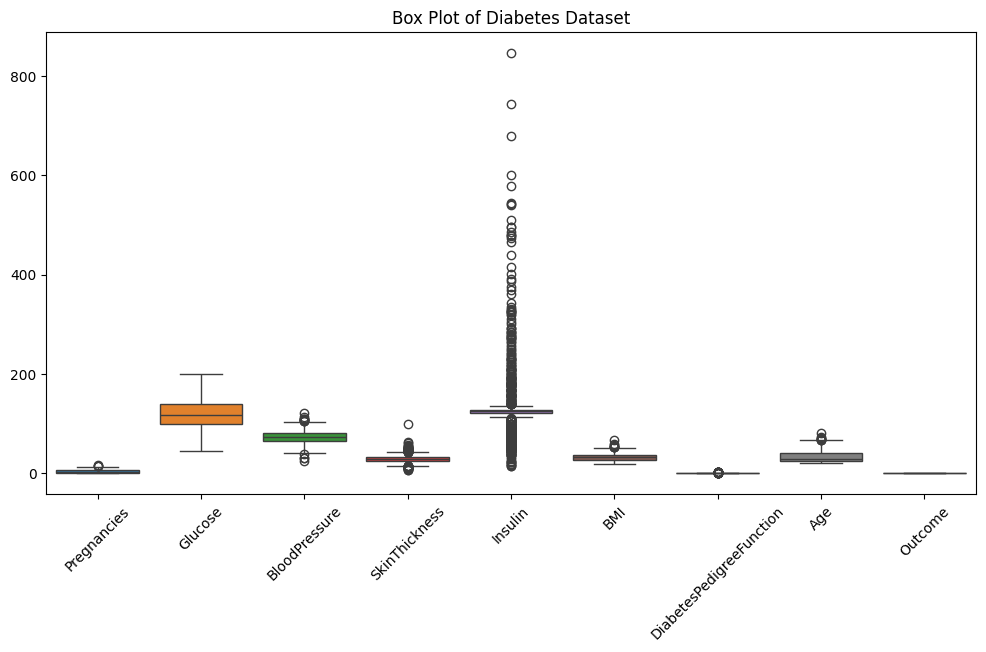

In [83]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df_clean)

plt.title("Box Plot of Diabetes Dataset")
plt.xticks(rotation=45)
plt.show()

In [44]:
df.duplicated().sum()

np.int64(0)

In [45]:
# Box-Plot

zero_columns= ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
zero_counts = (df[zero_columns] == 0).sum()

print("Zero Value:")
print(zero_counts)

Zero Value:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [46]:
df_clean = df.copy()

df_clean[zero_columns] = df_clean[zero_columns].replace(0,np.nan)
print("Missing Value after replacing invalid zero:")
print(df_clean.isnull().sum())

Missing Value after replacing invalid zero:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [47]:
for col in zero_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Missing values after median imputation")
print(df_clean.isnull().sum())


Missing values after median imputation
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [48]:
X= df_clean.drop("Outcome",axis=1)

y=df_clean["Outcome"]
print("X Shape:",X.shape)
print("y Shape:",y.shape)

X Shape: (768, 8)
y Shape: (768,)


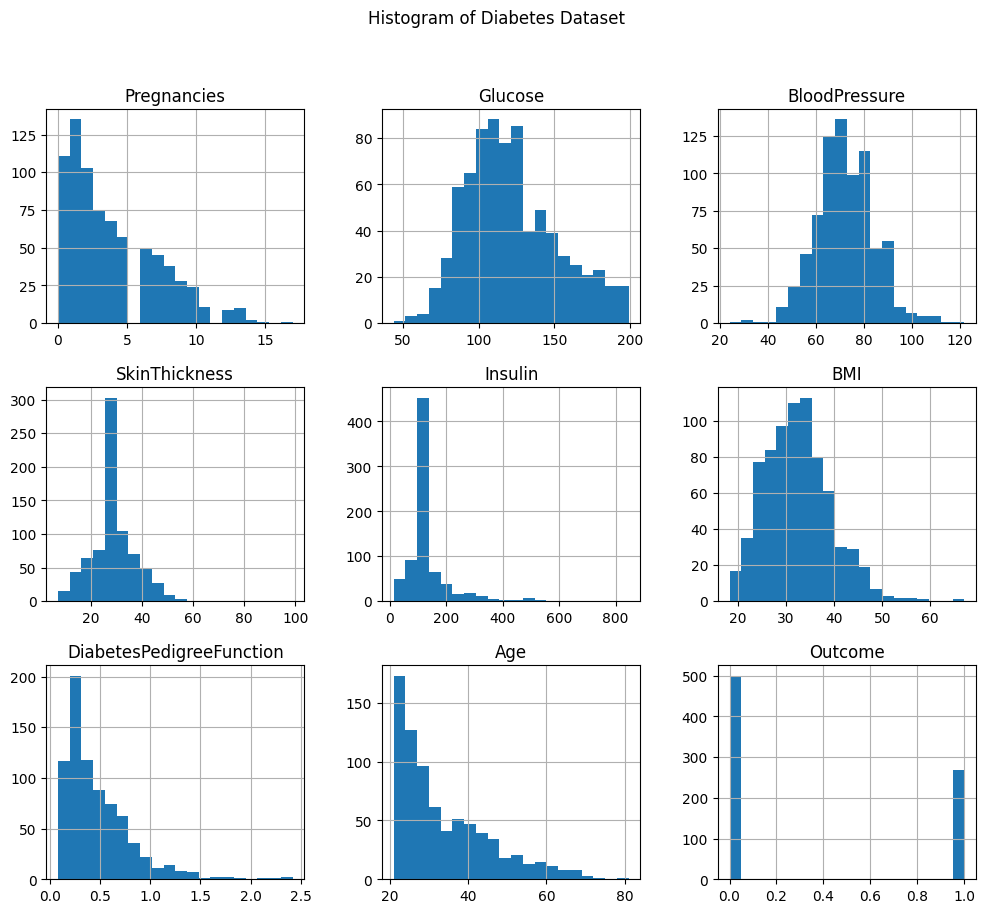

In [84]:
df_clean.hist(
    figsize=(12, 10),
    bins=20
)

plt.suptitle("Histogram of Diabetes Dataset")
plt.show()

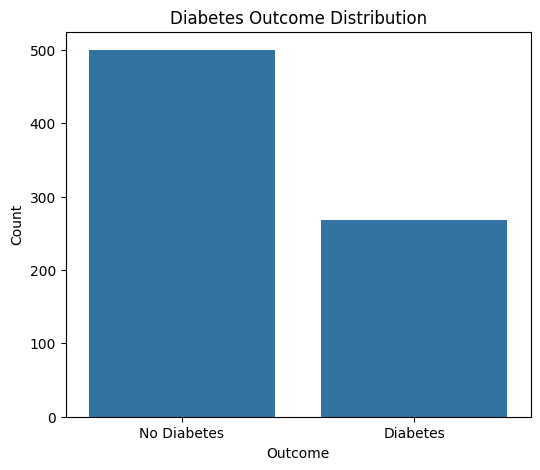

In [85]:
plt.figure(figsize=(6, 5))

sns.countplot(
    data=df_clean,
    x="Outcome"
)

plt.xticks(
    [0, 1],
    ["No Diabetes", "Diabetes"]
)

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Count")

plt.show()

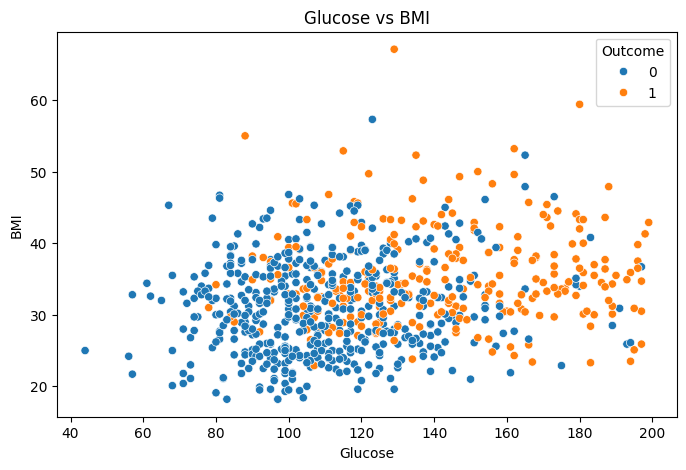

In [86]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_clean,
    x="Glucose",
    y="BMI",
    hue="Outcome"
)

plt.title("Glucose vs BMI")
plt.xlabel("Glucose")
plt.ylabel("BMI")

plt.show()

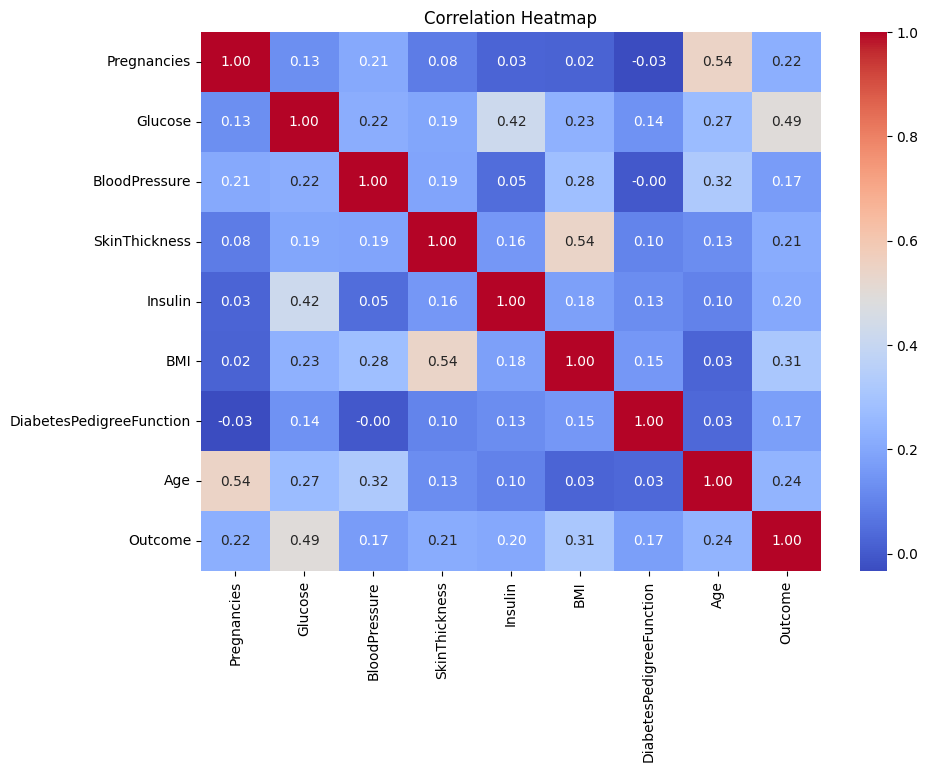

In [87]:
plt.figure(figsize=(10, 7))

correlation = df_clean.corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

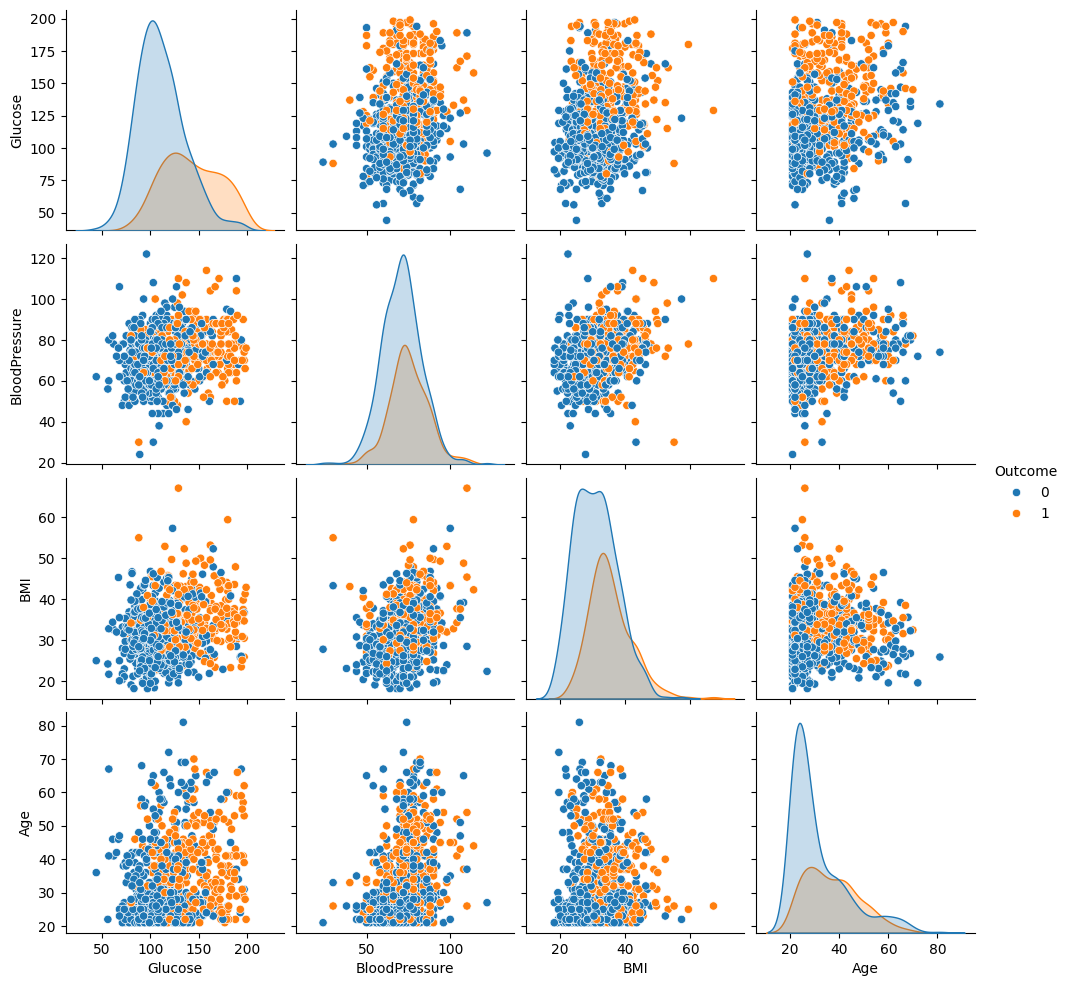

In [88]:
features = [
    "Glucose",
    "BloodPressure",
    "BMI",
    "Age",
    "Outcome"
]

sns.pairplot(
    df_clean[features],
    hue="Outcome"
)

plt.show()

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 614
Testing samples: 154


In [50]:
print("training distribution:")
print(y_train.value_counts(normalize=True))

print("\ntraining distribution:")
print(y_test.value_counts(normalize=True))


training distribution:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

training distribution:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


In [51]:
scaler= StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)

X_test_scaled= scaler.transform(X_test)

In [52]:
scaler.fit_transform(X_test)

array([[ 0.85252995,  1.16484536, -0.8288433 , ..., -0.71933141,
        -0.46562514,  0.63400979],
       [ 1.69054875, -1.66920722,  2.88630463, ...,  0.42561436,
        -0.49253293,  1.24533587],
       [-0.54416805,  0.01253827,  0.23262754, ...,  0.48215489,
         0.09943846, -0.58864236],
       ...,
       [-0.54416805, -1.23319913, -1.89031414, ..., -0.56384494,
         3.73497988, -0.67597466],
       [ 0.01451115,  1.94343123,  0.40953934, ...,  0.63764135,
        -0.55531777, -0.15198088],
       [-0.82350765, -1.57577692,  0.40953934, ...,  0.1005063 ,
        -0.08293657, -1.02530385]])

In [53]:
scaler.transform(X_test)

array([[ 0.85252995,  1.16484536, -0.8288433 , ..., -0.71933141,
        -0.46562514,  0.63400979],
       [ 1.69054875, -1.66920722,  2.88630463, ...,  0.42561436,
        -0.49253293,  1.24533587],
       [-0.54416805,  0.01253827,  0.23262754, ...,  0.48215489,
         0.09943846, -0.58864236],
       ...,
       [-0.54416805, -1.23319913, -1.89031414, ..., -0.56384494,
         3.73497988, -0.67597466],
       [ 0.01451115,  1.94343123,  0.40953934, ...,  0.63764135,
        -0.55531777, -0.15198088],
       [-0.82350765, -1.57577692,  0.40953934, ...,  0.1005063 ,
        -0.08293657, -1.02530385]])

In [54]:
comparison = pd.DataFrame({
    "Orginial Mean": X_train.mean(),
    "Orginial std": X_train.std(),
    "Scaled Mean": X_train_scaled.mean(axis=0),
    "Scaled std": X_train_scaled.std(axis=0)
})

display(comparison)

,Orginial Mean,Orginial std,Scaled Mean,Scaled std
Pregnancies,3.819218,3.314148,-6.943414e-17,1.0
Glucose,121.671010,30.003794,-1.099374e-16,1.0
BloodPressure,72.140065,12.275119,3.095606e-16,1.0
SkinThickness,29.042345,8.891855,-3.471707e-17,1.0
Insulin,137.705212,78.764767,-4.339634e-18,1.0
BMI,32.446743,6.824142,-1.148556e-15,1.0
DiabetesPedigreeFunction,0.477428,0.330300,-1.099374e-16,1.0
Age,33.366450,11.833438,-1.084908e-16,1.0


In [55]:
K= 5


In [56]:
knn=KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled,y_train)

KNeighborsClassifier()

In [57]:
y_pred=knn.predict(X_test_scaled)

print("Predictions:")
print(y_pred[:20])

Predictions:
[1 0 0 1 0 0 0 1 0 1 0 1 0 0 0 1 1 0 1 0]


In [58]:
y_prob=knn.predict_proba(X_test_scaled)[:,1]

print(y_prob[:20])

[0.6 0.2 0.2 0.6 0.  0.2 0.2 0.8 0.  0.6 0.4 0.6 0.  0.  0.  0.6 0.8 0.
 1.  0.2]


In [59]:
accuracy = accuracy_score(y_test,y_pred)
print(f"Accuracy:{accuracy:.4f}")

Accuracy:0.7532


In [60]:
precision = precision_score(y_test, y_pred)
print(f"Precision: {precision:.4f}")

Precision: 0.6600


In [61]:
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.4f}")

Recall: 0.6111


In [62]:
f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1:.4f}")

F1 Score: 0.6346


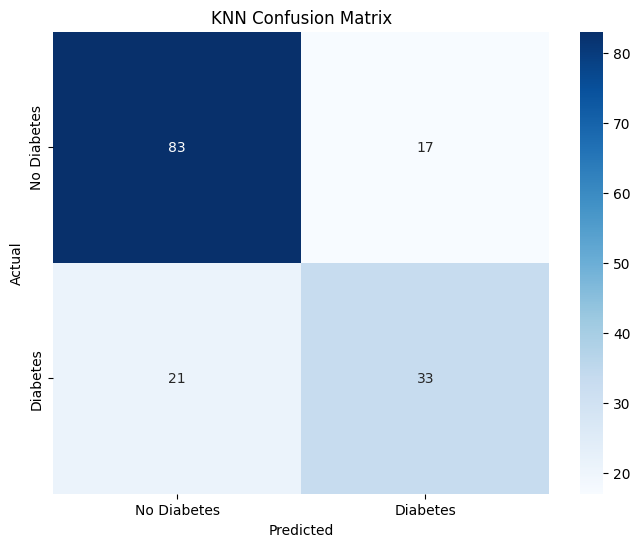

In [63]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")

plt.show()

In [64]:
k_values = range(1,31)

train_accuracies = []
test_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    train_test_split_accuracy = knn.score(X_train_scaled, y_train)
    test_accuracy = knn.score(X_test_scaled, y_test)

    train_accuracies.append(train_test_split_accuracy)
    test_accuracies.append(test_accuracy)

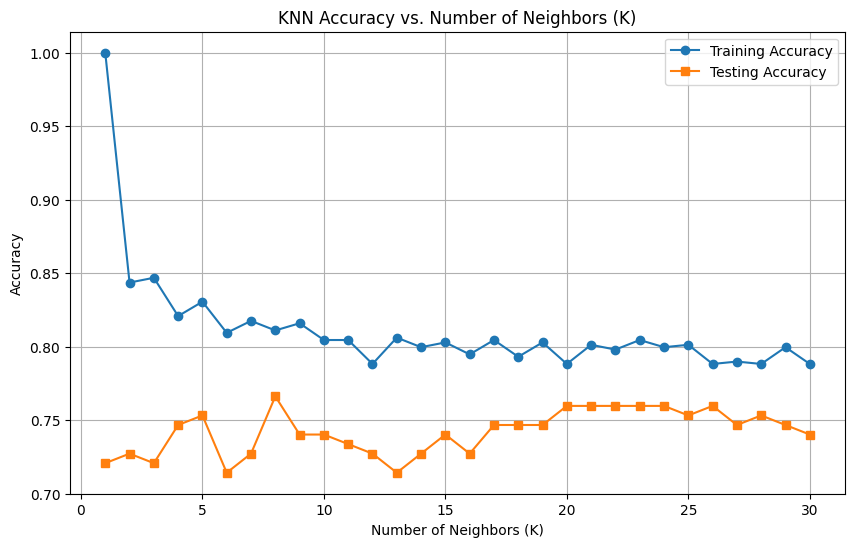

In [71]:
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_accuracies, marker='o', label='Training Accuracy')
plt.plot(k_values, test_accuracies, marker='s', label='Testing Accuracy')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy vs. Number of Neighbors (K)')
plt.legend()
plt.grid(True)
plt.show()

In [74]:
best_k = k_values[np.argmax(test_accuracies)]
best_accuracy = max(test_accuracies)

print(f"Best K value: {best_k}")
print(f"Best Accuracy: {best_accuracy:.4f}")

Best K value: 8
Best Accuracy: 0.7662


In [76]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []

for k in range(1,31):
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    cv_scores.append(scores.mean())

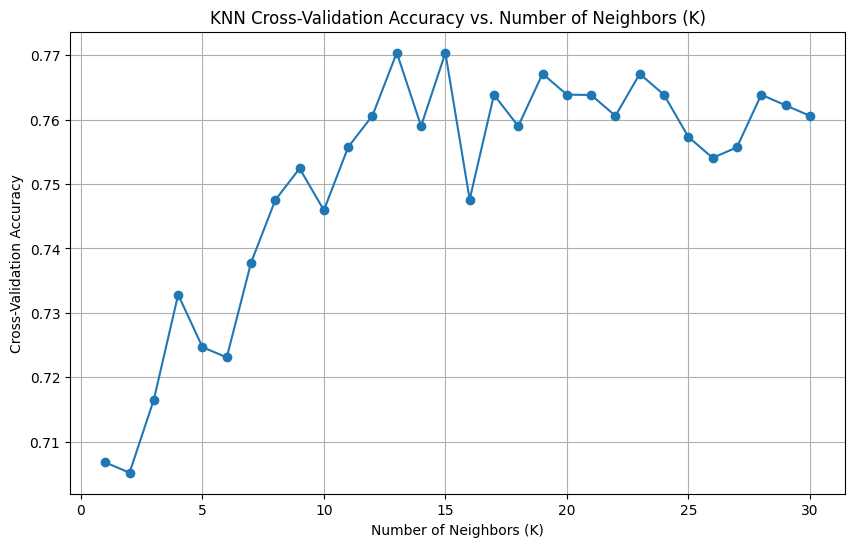

In [77]:
plt.figure(figsize=(10, 6))
plt.plot(range(1,31), cv_scores, marker='o')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Cross-Validation Accuracy')
plt.title('KNN Cross-Validation Accuracy vs. Number of Neighbors (K)')
plt.grid(True)
plt.show()

In [78]:
best_k = range(1,31)[np.argmax(cv_scores)]
best_accuracy = max(cv_scores)

print(f"Best K value: {best_k}")
print(f"Best Accuracy: {best_accuracy:.4f}")

Best K value: 13
Best Accuracy: 0.7704


In [79]:
param_grid={"n_neighbors":list(range(3,31,2)),"weights":["uniform","distance"],"metric": ["euclidean","manhattan","minkowski"],
"p":[1,2]
}

In [80]:
grid_search= GridSearchCV(estimator=KNeighborsClassifier(),param_grid=param_grid,cv=5, scoring="accuracy",n_jobs=-1)


grid_search.fit(X_train_scaled,y_train)


print("Grid Search completed:")

Grid Search completed:


In [81]:
print("Best Parameters:",grid_search.best_params_)
print("Best Score:",grid_search.best_score_)

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 19, 'p': 1, 'weights': 'uniform'}
Best Score: 0.7769025723044115


In [82]:
best_knn = grid_search.best_estimator_

print(best_knn)

KNeighborsClassifier(metric='euclidean', n_neighbors=19, p=1)
